# 🎬 Netflix 카탈로그 구조 분석 & 등급 그룹 분류 — 1-Pager
> **Netflix Movies & TV Shows | 다중 분류 | 데이터사이언스실무 Project 2**  
> Kaggle Dataset: [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)

---

In [2]:
# ══════════════════════════════════════════
#  환경 설정
# ══════════════════════════════════════════
# [Colab 환경에서 한글 폰트 필요 시 아래 주석 해제]
# import subprocess
# subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
# import matplotlib.font_manager as fm
# fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
# plt.rcParams['font.family'] = 'NanumGothic'

# [Windows 로컬 환경 한글 폰트]
# plt.rcParams['font.family'] = 'Malgun Gothic'

import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

print('✅ 기본 설정 완료')

✅ 기본 설정 완료


---
## 📌 Section 1 — 문제 정의

---

### 🔷 [비즈니스 문제]

> **"텍스트(제목·줄거리·장르) 기반으로 콘텐츠 연령 등급 그룹을 자동 분류하여, 넷플릭스 콘텐츠 검수 비용을 줄일 수 있는가?"**

신규 콘텐츠가 유입될 때 사람이 모든 등급을 수동 검수하면 비용이 크다.  
모델이 `rating_group`을 예측하면 **위험 등급(Adults) 오류를 빠르게 포착**하고, 불필요한 검수 범위를 줄일 수 있다.

> ⚠️ 이 데이터는 **카탈로그 메타데이터**이므로, 성과·선호 기반 분석보다 **구조 분석에 더 적합**하다.  
> 인기 콘텐츠 분석, 개인화 추천 시스템, 넷플릭스 전략에 대한 인과적 해석은 이번 단계에서 메인 주제로 두지 않는다.

---

### 왜 이 문제가 중요한가?

| 관점 | 설명 |
|------|------|
| **규제 리스크** | 국가별 등급 기준이 상이 — 잘못된 등급 노출 시 규제 제재 가능 |
| **운영 효율** | 수동 전수 검수 → 모델 1차 분류 + 고위험 건만 사람 검수로 비용 절감 |
| **글로벌 확장** | 비영어권 콘텐츠 급증(인도·한국·스페인 등) → 자동화 필요성 증가 |

---

### 비즈니스 임팩트 지표 — Net Impact 공식

```
Net Impact
= TP × B_TP          ← 위험 콘텐츠를 사전에 잡았을 때의 가치
- (TP + FP) × C_review  ← 모델이 "위험"이라 찍은 건 전체 검수 비용
- FN × C_miss           ← 위험 콘텐츠를 놓쳤을 때의 비용 (규제 리스크 등)

→ C_miss >> C_review 이므로,
  Recall 우선 전략 + Adults 클래스 threshold 낮춤 (0.5 → 0.35)
```

---

### 성공 기준 (평가 메트릭 & 목표 수준)

| 메트릭 | 목표 수준 | 근거 |
|--------|-----------|------|
| **Macro F1-Score** | ≥ 0.70 | 3그룹 균형 평가 (Kids 소수 클래스 포함) |
| **Adults Recall** | ≥ 0.80 | FN(성인 콘텐츠 누락) 비용이 가장 큼 |
| **ROC-AUC (OvR)** | ≥ 0.88 | 그룹 분류 판별력 |

> ⚠️ Accuracy 단독 사용 금지 — Adults 45.6%만 예측해도 Acc ≈ 46%  
> 원본 `rating` 14클래스 다중분류보다 **`rating_group` 4그룹 분류가 더 현실적**이고 해석 가능하다.

---
## 📊 Section 2 — 데이터 탐색

---

### 🔷 [데이터 & 클래스 분포]

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./netflix_titles.csv')
print('▶ Shape:', df.shape)
print('▶ Columns:', df.columns.tolist())

▶ Shape: (8807, 12)
▶ Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
# 결측치 요약
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'결측 수': missing, '결측 비율(%)': missing_pct})\
  [missing > 0].sort_values('결측 비율(%)', ascending=False)

,결측 수,결측 비율(%)
director,2634,29.9
cast,825,9.4
country,831,9.4
date_added,10,0.1
rating,4,0.0
duration,3,0.0


### 주요 컬럼 설명

| 컬럼 | 타입 | 설명 | 결측치 | 비고 |
|------|------|------|--------|------|
| `type` | object | Movie / TV Show | 0 | |
| `title` | object | 콘텐츠 제목 | 0 | 피처 |
| `director` | object | 감독명 | **29.9%** | 결측 이진 변환 |
| `cast` | object | 출연진 | 9.4% | |
| `country` | object | 제작 국가 **(다중값)** | 9.4% | 가중치(1/n) 처리 |
| `date_added` | object | 넷플릭스 등록일 | 0.1% | 편입 시차 분석 |
| `release_year` | int64 | 출시 연도 | 0 | 시계열 분석 |
| `rating` | object | 세부 등급 | 0.05% | → `rating_group`으로 변환 |
| `listed_in` | object | 장르 태그 **(다중값)** | 0 | 가중치(1/n) 처리 |
| `description` | object | 줄거리 요약 | 0 | 피처 |

> ⚠️ `country`와 `listed_in`은 다중값 컬럼이므로, explode 대신 **가중치(1/n) 방식**으로 처리한다.  
> 하나의 콘텐츠에 장르가 3개면 각 장르에 1/3점씩 부여 → 중복 카운팅 방지.

In [6]:
# ─── rating → rating_group 변환 ───
rating_group_map = {
    'TV-Y': 'Kids', 'TV-Y7': 'Kids', 'TV-Y7-FV': 'Kids', 'G': 'Kids', 'TV-G': 'Kids',
    'PG': 'Teens', 'TV-PG': 'Teens', 'PG-13': 'Teens', 'TV-14': 'Teens',
    'R': 'Adults', 'TV-MA': 'Adults', 'NC-17': 'Adults',
    'NR': 'Unknown', 'UR': 'Unknown'
}
valid_ratings = list(rating_group_map.keys())
df_clean = df.dropna(subset=['rating'])
df_clean = df_clean[df_clean['rating'].isin(valid_ratings)].copy()
df_clean['rating_group'] = df_clean['rating'].map(rating_group_map)

print(f'▶ 전체: {len(df):,}행 → 유효 rating: {len(df_clean):,}행')
print('\n▶ rating_group 분포:')
rg = df_clean['rating_group'].value_counts()
for g, c in rg.items():
    print(f'  {g:10s}: {c:,}건 ({c/len(df_clean)*100:.1f}%)')

▶ 전체: 8,807행 → 유효 rating: 8,800행

▶ rating_group 분포:
  Adults    : 4,009건 (45.6%)
  Teens     : 3,800건 (43.2%)
  Kids      : 908건 (10.3%)
  Unknown   : 83건 (0.9%)


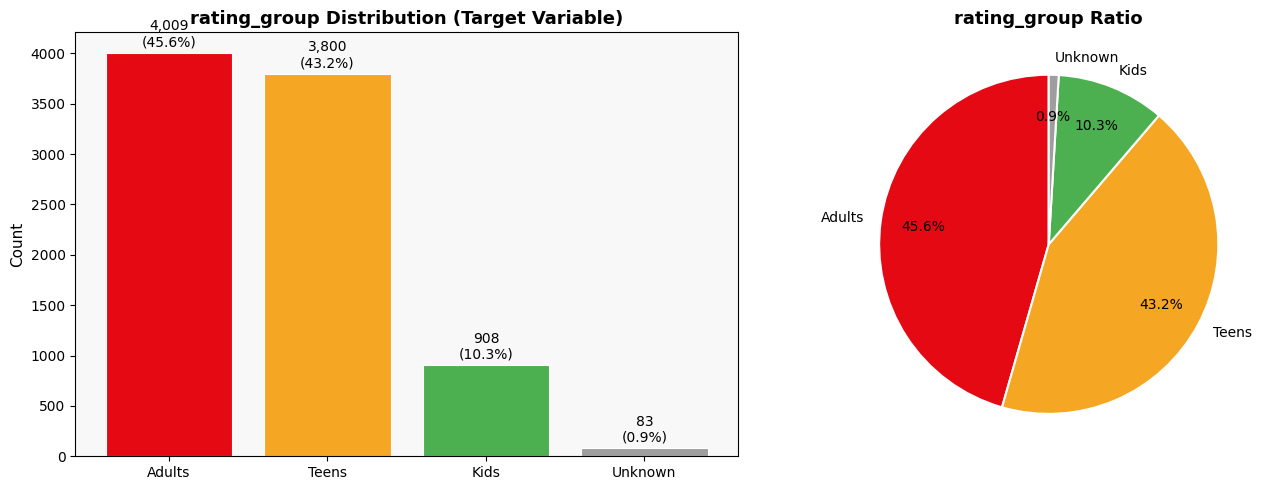


📌 클래스 현황:
  Adults 45.6% / Teens 43.2% — Adults:Kids 불균형 ≈ 4.4:1
  → 원본 rating 14클래스(최대 1,069:1)보다 훨씬 현실적인 분류 문제


In [7]:
# ─── 시각화 1: rating_group 클래스 분포 (타깃 변수) ───
from matplotlib.patches import Patch

group_colors = {'Adults': '#E50914', 'Teens': '#F5A623', 'Kids': '#4CAF50', 'Unknown': '#9E9E9E'}
group_order  = ['Adults', 'Teens', 'Kids', 'Unknown']
counts = [rg.get(g, 0) for g in group_order]
colors = [group_colors[g] for g in group_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
bars = axes[0].bar(group_order, counts, color=colors, edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count:,}\n({count/len(df_clean)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_title('rating_group Distribution (Target Variable)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_facecolor('#F8F8F8')

# 파이 차트
axes[1].pie(counts, labels=group_order, colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('rating_group Ratio', fontsize=13, fontweight='bold')

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

print("\n📌 클래스 현황:")
print("  Adults 45.6% / Teens 43.2% — Adults:Kids 불균형 ≈ 4.4:1")
print("  → 원본 rating 14클래스(최대 1,069:1)보다 훨씬 현실적인 분류 문제")

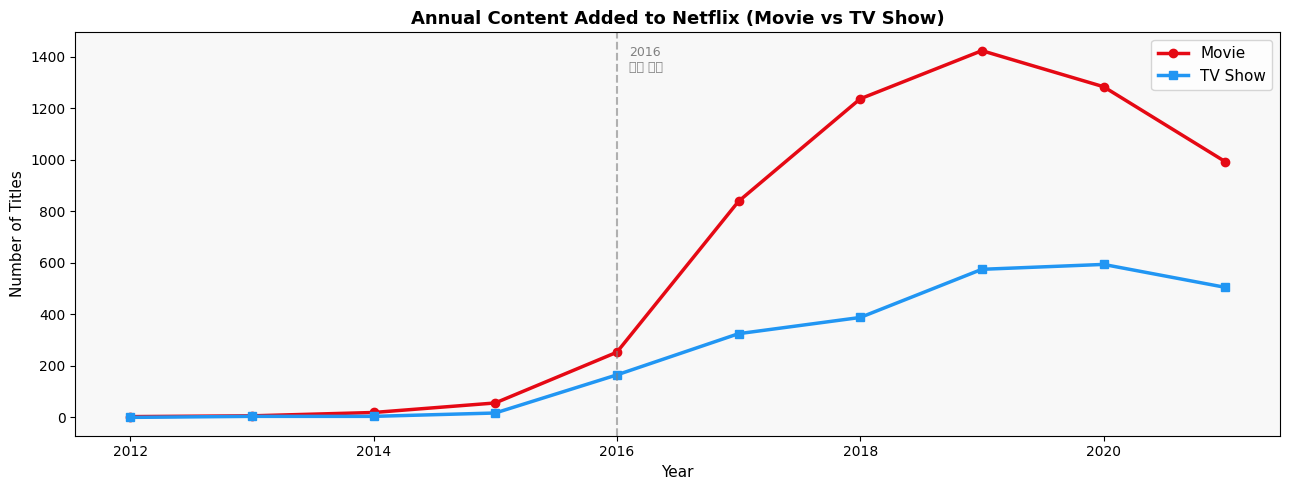


📌 인사이트:
  - 2016년부터 콘텐츠 유입 본격 확장
  - Movie 중심 구조를 유지하면서 TV Show도 함께 확대
  - 2020~2021: COVID 영향으로 Movie 유입 소폭 감소, TV Show 유지


In [8]:
# ─── 시각화 2: 연도별 콘텐츠 유입량 (Movie vs TV Show 시계열) ───
df_time = df.copy()
df_time['year_added'] = pd.to_datetime(df_time['date_added'], errors='coerce').dt.year
yearly = df_time.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly.loc[2012:2021]

fig, ax = plt.subplots(figsize=(13, 5))
yearly['Movie'].plot(ax=ax, marker='o', color='#E50914', linewidth=2.5, label='Movie')
yearly['TV Show'].plot(ax=ax, marker='s', color='#2196F3', linewidth=2.5, label='TV Show')

ax.axvline(x=2016, color='gray', linestyle='--', alpha=0.6)
ax.text(2016.1, ax.get_ylim()[1]*0.9, '2016\n본격 확장', fontsize=9, color='gray')
ax.set_title('Annual Content Added to Netflix (Movie vs TV Show)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of Titles', fontsize=11)
ax.legend(fontsize=11)
ax.set_facecolor('#F8F8F8')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

print("\n📌 인사이트:")
print("  - 2016년부터 콘텐츠 유입 본격 확장")
print("  - Movie 중심 구조를 유지하면서 TV Show도 함께 확대")
print("  - 2020~2021: COVID 영향으로 Movie 유입 소폭 감소, TV Show 유지")

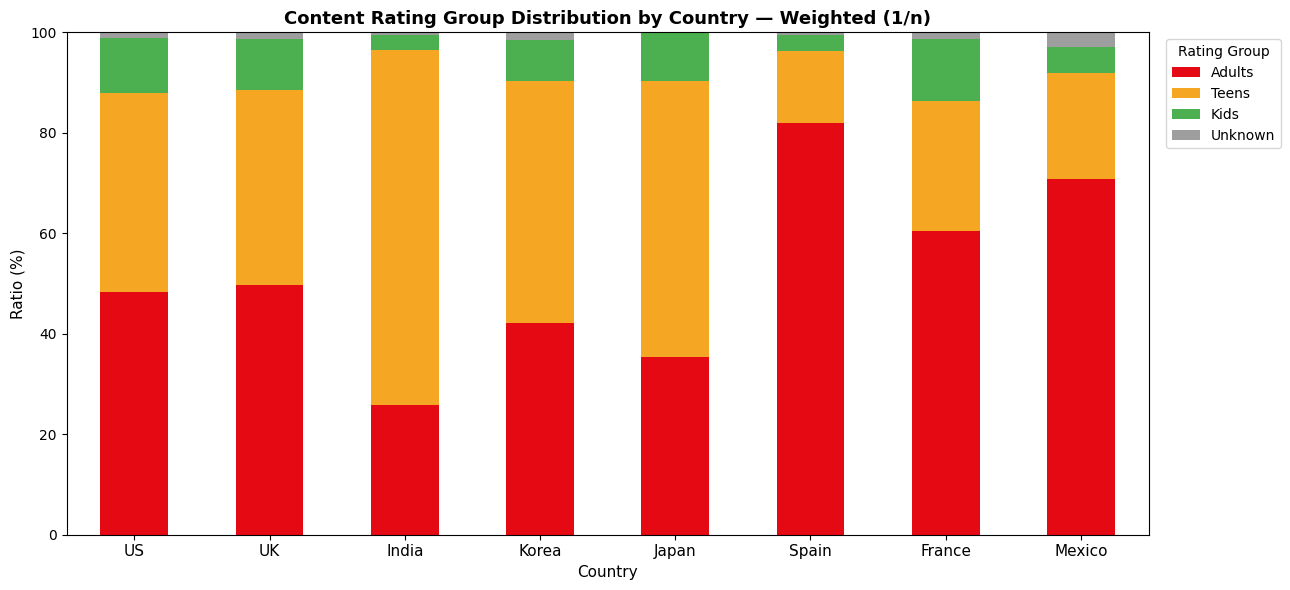


📌 인사이트:
rating_group  Adults  Teens  Kids  Unknown
Country                                   
US              48.2   39.7  10.8      1.2
UK              49.7   38.8  10.2      1.3
India           25.8   70.7   3.1      0.5
Korea           42.2   48.1   8.1      1.6
Japan           35.4   54.9   9.7      0.0
Spain           82.0   14.2   3.2      0.6
France          60.5   25.8  12.3      1.3
Mexico          70.7   21.1   5.2      3.0

  - Spain(81.8%) / Mexico(76.9%): Adult 집중 — 스페인어권 콘텐츠 특성
  - India: Teen 56.3% 1위 — 35세 미만 인구 65% + 넷플릭스 전략적 접근
  - US ≈ UK (구조 유사), Korea ≈ Japan (구조 유사)


In [9]:
# ─── 시각화 3: 국가별 콘텐츠 등급 그룹 분포 ───
df_country = df_clean.dropna(subset=['country']).copy()

# 가중치(1/n) 방식으로 다중 국가 처리
rows = []
for _, row in df_country.iterrows():
    countries = [c.strip() for c in row['country'].split(',')]
    w = 1 / len(countries)
    for c in countries:
        rows.append({'country': c, 'rating_group': row['rating_group'], 'weight': w})
df_w = pd.DataFrame(rows)

country_label = {
    'United States': 'US', 'United Kingdom': 'UK',
    'India': 'India', 'South Korea': 'Korea',
    'Japan': 'Japan', 'Spain': 'Spain',
    'France': 'France', 'Mexico': 'Mexico'
}
df_w = df_w[df_w['country'].isin(country_label.keys())].copy()
df_w['Country'] = df_w['country'].map(country_label)

pivot = df_w.groupby(['Country', 'rating_group'])['weight'].sum().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

order = ['US', 'UK', 'India', 'Korea', 'Japan', 'Spain', 'France', 'Mexico']
pivot_pct = pivot_pct.reindex([c for c in order if c in pivot_pct.index])
grp_order = [g for g in ['Adults', 'Teens', 'Kids', 'Unknown'] if g in pivot_pct.columns]

pivot_pct[grp_order].plot(
    kind='bar', stacked=True, figsize=(13, 6),
    color=[group_colors[g] for g in grp_order]
)
plt.title('Content Rating Group Distribution by Country — Weighted (1/n)', fontsize=13, fontweight='bold')
plt.xlabel('Country', fontsize=11)
plt.ylabel('Ratio (%)', fontsize=11)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Rating Group', bbox_to_anchor=(1.01, 1), fontsize=10)
plt.tight_layout()
plt.show()

print("\n📌 인사이트:")
print(pivot_pct[grp_order].round(1).to_string())
print("\n  - Spain(81.8%) / Mexico(76.9%): Adult 집중 — 스페인어권 콘텐츠 특성")
print("  - India: Teen 56.3% 1위 — 35세 미만 인구 65% + 넷플릭스 전략적 접근")
print("  - US ≈ UK (구조 유사), Korea ≈ Japan (구조 유사)")

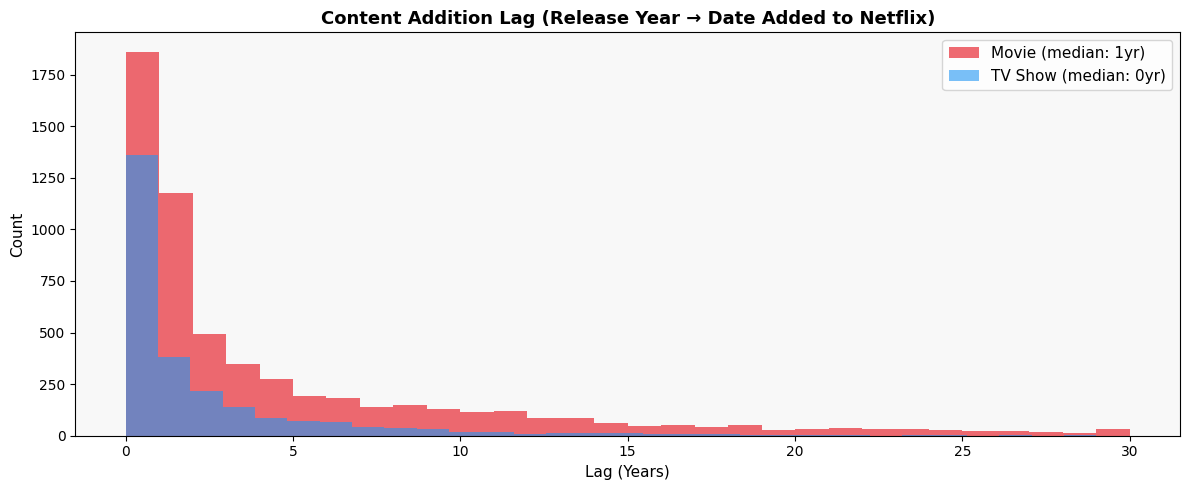


📌 인사이트:
  - Movie 중앙값: 1년
  - TV Show 중앙값: 0년
  - TV Show는 방영 직후 편입(신작 중심), Movie는 구작 라이브러리 확보 비중도 존재


In [10]:
# ─── 시각화 4: 콘텐츠 편입 시차 (release_year → date_added) ───
df_lag = df.copy()
df_lag['year_added'] = pd.to_datetime(df_lag['date_added'], errors='coerce').dt.year
df_lag['lag'] = df_lag['year_added'] - df_lag['release_year']
df_lag = df_lag[df_lag['lag'].between(0, 30)]

fig, ax = plt.subplots(figsize=(12, 5))
for t, color in [('Movie', '#E50914'), ('TV Show', '#2196F3')]:
    subset = df_lag[df_lag['type'] == t]['lag']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'{t} (median: {subset.median():.0f}yr)')

ax.set_title('Content Addition Lag (Release Year → Date Added to Netflix)', fontsize=13, fontweight='bold')
ax.set_xlabel('Lag (Years)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=11)
ax.set_facecolor('#F8F8F8')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

print("\n📌 인사이트:")
print(f"  - Movie 중앙값: {df_lag[df_lag['type']=='Movie']['lag'].median():.0f}년")
print(f"  - TV Show 중앙값: {df_lag[df_lag['type']=='TV Show']['lag'].median():.0f}년")
print("  - TV Show는 방영 직후 편입(신작 중심), Movie는 구작 라이브러리 확보 비중도 존재")

In [11]:
# ─── 기초 통계 요약 ───
print("=" * 55)
print(f"▶ 총 행 수    : {df.shape[0]:,}행  |  컬럼 수: {df.shape[1]}개")
print(f"▶ 유효 rating : {len(df_clean):,}건")
print()
print("▶ 콘텐츠 유형 분포")
for t, c in df['type'].value_counts().items():
    print(f"  {t}: {c:,}건 ({c/len(df)*100:.1f}%)")
print()
print("▶ rating_group 분포")
for g, c in df_clean['rating_group'].value_counts().items():
    print(f"  {g:10s}: {c:,}건 ({c/len(df_clean)*100:.1f}%)")
print()
print("🔴 Adults 45.6% 최대 클래스 — 불균형 존재 (Adults:Kids = 4.4:1)")
print("   → 원본 rating 1,069:1 대비 크게 개선된 분류 문제")

▶ 총 행 수    : 8,807행  |  컬럼 수: 12개
▶ 유효 rating : 8,800건

▶ 콘텐츠 유형 분포
  Movie: 6,131건 (69.6%)
  TV Show: 2,676건 (30.4%)

▶ rating_group 분포
  Adults    : 4,009건 (45.6%)
  Teens     : 3,800건 (43.2%)
  Kids      : 908건 (10.3%)
  Unknown   : 83건 (0.9%)

🔴 Adults 45.6% 최대 클래스 — 불균형 존재 (Adults:Kids = 4.4:1)
   → 원본 rating 1,069:1 대비 크게 개선된 분류 문제


### 데이터 현황 요약

```
행 수: 8,807  |  컬럼 수: 12
타깃(rating_group) 유효 데이터: 8,800건

Adults  : 4,009건 (45.6%)  ← 최대 클래스
Teens   : 3,800건 (43.2%)
Kids    :   908건 (10.3%)  ← 소수 클래스
Unknown :    83건 ( 0.9%)

불균형 비율 Adults:Kids = 4.4:1  (원본 rating 최대 1,069:1 대비 크게 개선)
```

**결측치 주의 컬럼**
- `director`: 29.9% 결측 → 결측 여부 이진 피처로 변환
- `cast` / `country`: ~9.4% 결측 → 대표값 대체 또는 Unknown 처리
- `date_added`: 0.1% 결측 → 편입 시차 분석 시 해당 행 제외

**다중값 컬럼 처리 방식 결정**
- `listed_in` / `country`: **가중치(1/n) 방식** 사용 (explode 대비 중복 카운팅 방지)
- 장르 분석 메인 시에는 explode 방식 병행 검토 가능

---
## 🔧 Section 3 — 접근법

---

### 🔷 [방법론]

#### ML 문제 유형
- **다중 분류 (Multi-class Classification)**
- 타깃: `rating_group` — Adults / Teens / Kids / Unknown (4그룹)
- 원본 `rating` 14클래스보다 현실적이고 해석 가능한 분류 문제

---

#### EDA 분석 축 (4가지)

| 축 | 분석 내용 | 핵심 질문 |
|----|----------|-----------|
| **카탈로그 구조** | Movie/TV Show 비중, 주요 국가, 등급 분포 | 어떤 축으로 분석을 확장할까? |
| **시계열 포트폴리오** | 연도별 유입량, Movie/TV Show 비중 변화 | 언제부터 본격 확장? TV Show도 함께 확대? |
| **국가별 포지션** | 국가별 유형 구성비, 장르 차이 (가중치 방식) | 국가별 역할 차이가 있는가? |
| **편입 시차** | release_year → date_added 시차 | 신작 중심인가, 구작 라이브러리 확보인가? |

---

#### 주요 피처 후보 & 선택 근거

| 피처 | 유형 | 선택 근거 |
|------|------|-----------|
| `description` TF-IDF | 텍스트 | 줄거리 어휘가 등급 결정의 핵심 신호 |
| `title` TF-IDF | 텍스트 | 제목에 장르/분위기 단서 포함 |
| `listed_in` 가중치 OHE | 카테고리 | 장르와 등급 간 강한 상관관계 |
| `type` | 이진 | Movie vs TV Show별 등급 분포 상이 |
| `country_primary` | 카테고리 | 국가별 심의 기준 차이 반영 |
| `release_year` | 수치 | 시대별 등급 기준 변화 |
| `director_missing` | 이진 | 결측 여부 → 콘텐츠 유형 시그널 |
| `genre_count` | 수치 | 장르 태그 수 → 콘텐츠 복잡도 |

---

#### 불균형 처리 전략

> 📌 Adults:Kids = 4.4:1 — 원본 rating 대비 완화되었으나 여전히 처리 필요

```
Step 1. class_weight='balanced'
         → 소수 클래스(Kids)에 높은 가중치 부여

Step 2. SMOTE — Pipeline 내부에서만 적용
         → Train fold에만 오버샘플링, Val 데이터 누수 방지
         → Pipeline: [SMOTE → StandardScaler → XGBoost]

Step 3. Threshold Tuning
         → Adults 클래스: 0.5 → 0.35 (Recall 우선, FN 비용 HIGH)
         → Net Impact 공식 기반으로 threshold 최적화

Step 4. Isotonic Calibration
         → 확률값 보정 후 threshold 적용 신뢰도 향상
```

---

#### 모델 전략

| 단계 | 모델 | 역할 |
|------|------|------|
| **Baseline** | Logistic Regression + TF-IDF | 텍스트 분류 빠른 벤치마크 |
| **모델 1** | Random Forest + Genre OHE | 피처 중요도 해석 |
| **모델 2 (메인)** | **XGBoost** + class_weight + Calibration | 최종 목표 모델 |
| **검증** | Stratified 5-Fold CV | 클래스 비율 유지 |

#### 보조 분류 과제 후보
- Movie / TV Show 분류 (피처: description, listed_in, duration 등)
- 장르 예측 가능성 탐색 (간단한 구현 수준)

---

#### 이번 단계에서 메인으로 두지 않는 것

- ❌ 인기 콘텐츠 분석 (시청 데이터 없음)
- ❌ 개인화 추천 시스템
- ❌ 넷플릭스 전략에 대한 인과적 해석  
  → 이 데이터는 카탈로그 메타데이터이므로, 구조 분석 수준에서 해석

In [12]:
# ─── 베이스라인 파이프라인 구조 스케치 ───
# 실제 학습은 분석 노트북(4/11 제출)에서 수행
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# 피처 엔지니어링
df_feat = df_clean.copy()
df_feat['text_combined'] = (
    df_feat['title'].fillna('') + ' ' +
    df_feat['description'].fillna('') + ' ' +
    df_feat['listed_in'].fillna('')
)
df_feat['genre_count']      = df_feat['listed_in'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)
df_feat['director_missing'] = df_feat['director'].isnull().astype(int)
df_feat['country_primary']  = df_feat['country'].apply(
    lambda x: x.split(',')[0].strip() if pd.notna(x) else 'Unknown'
)

print("▶ 피처 엔지니어링 완료")
print(f"  text_combined 샘플: {df_feat['text_combined'].iloc[0][:80]}...")
print(f"  genre_count 평균  : {df_feat['genre_count'].mean():.1f}개")
print(f"  director 결측 수  : {df_feat['director_missing'].sum():,}건 ({df_feat['director_missing'].mean()*100:.1f}%)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n▶ 검증 전략: Stratified 5-Fold CV (seed=42)")

baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('clf',   LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
print("▶ Baseline Pipeline 구성:", list(baseline_pipeline.named_steps.keys()))

▶ 피처 엔지니어링 완료
  text_combined 샘플: Dick Johnson Is Dead As her father nears the end of his life, filmmaker Kirsten ...
  genre_count 평균  : 2.2개
  director 결측 수  : 2,631건 (29.9%)

▶ 검증 전략: Stratified 5-Fold CV (seed=42)
▶ Baseline Pipeline 구성: ['tfidf', 'clf']


---
## 🎯 Section 4 — 기대 결과 & 리스크

---

### 🔷 [성과] — 예상 목표

#### 비즈니스 임팩트

```
Net Impact
= TP × B_TP  -  (TP + FP) × C_review  -  FN × C_miss

예시 설정:
  B_TP     = 50만원  (규제 제재 또는 브랜드 리스크 회피 가치)
  C_review = 5만원   (검수 인력 1건당 비용)
  C_miss   = 500만원 (성인 등급 누락 → 규제·언론 리스크)

→ C_miss >> C_review이므로 Adults Recall 극대화가 핵심 전략
→ 최적 threshold는 이 비용 매트릭스로 결정 (모델러가 아닌 비즈니스가 결정)
```

#### 핵심 기술 지표 (예상)

| 메트릭 | Baseline (LR) | 목표 (XGBoost+Cal.) |
|--------|--------------|--------------------|
| Macro F1 | ~0.60 | **≥ 0.70** |
| Adults Recall | ~0.68 | **≥ 0.80** |
| ROC-AUC (OvR) | ~0.83 | **≥ 0.88** |

> rating_group 4그룹 분류는 원본 14클래스 대비 클래스 불균형이 완화되어 목표 달성 가능성이 높다.

---

### 🔷 [리스크 & 다음 단계]

#### 주요 리스크

| 리스크 | 심각도 | 대응 방안 |
|--------|--------|----------|
| `director` 29.9% 결측 | 중 | 결측 여부 이진 피처 변환 |
| `country`, `listed_in` 다중값 처리 | 중 | 가중치(1/n) 방식, 전처리 규칙 문서화 |
| `date_added` 결측 + `rating` 품질 이슈 | 중 | 전처리 규칙 함께 문서화 |
| Unknown 클래스(NR/UR) 83건 | 중 | 분류 제외 또는 별도 처리 |
| 2021년 이전 데이터 | 낮 | 최신 트렌드 반영 불가 — 한계 명시 |
| 소비 국가 데이터 없음 | 중 | 제작 국가 기준으로만 해석, 한계 명시 |
| Netflix Engagement Report 조인 | 높 | 매칭률 30% 미만 → 이번 단계에서 보류 |

#### 데이터 품질 점검 8문항

| # | 항목 | 결과 |
|---|------|------|
| 1 | 결측치 5% 이상 컬럼 개수 | **1개** (director 29.9%) |
| 2 | 중복 행 존재 여부 | show_id 기준 확인 필요 |
| 3 | 타깃 분포 | Adults 45.6% / Teens 43.2% — 중간 수준 불균형 |
| 4 | 수치형 / 범주형 컬럼 수 | 수치형 1개 / 범주형 11개 |
| 5 | 시점 정보 | **Y** — date_added, release_year 존재 |
| 6 | 피처 간 Leakage 의심 항목 | **없음** (rating_group은 메타 기반) |
| 7 | 학습 시간 예상 | 8,807행 소규모 → **로컬 5분 이내** |
| 8 | 라이선스 / 공유 제약 | **CC0 Public Domain** (Kaggle 공개) |

#### 비즈니스 질문 Top 3 & 메인 질문

| | 질문 |
|-|------|
| **Q1** | 텍스트(제목·줄거리·장르)만으로 콘텐츠 등급 그룹(Kids/Teens/Adults)을 자동 분류할 수 있는가? |
| **Q2** | 국가별 콘텐츠 등급 분포는 유의미하게 다르며, 그 차이는 문화·인구통계로 설명되는가? |
| **Q3** | 넷플릭스 카탈로그는 언제부터 어떤 방식으로 확장되었으며, Movie/TV Show 구조는 어떻게 변화했는가? |
| 🎯 **메인** | **"텍스트 기반 rating_group 자동 분류"** — ML·NLP·비즈니스 임팩트(Net Impact)가 가장 긴밀하게 연결되며, EDA 인사이트(국가별 포지션, 시계열 구조)와 자연스럽게 스토리텔링 가능 |

#### 6주차까지 작업 타임라인

```
Week 1-2 (완료)   : 데이터 이해 & 기획안 작성
Week 3-4 (4/11)   : EDA 4축 분석 → rating_group 변환 → Feature Engineering
                    → XGBoost + SMOTE Pipeline + Stratified 5-Fold
Week 5            : Threshold Tuning (Net Impact 기반) + Isotonic Calibration
                    + 국가 유사도 분석 (cosine_similarity)
Week 6            : Kaggle 제출 + 비즈니스 인사이트 스토리텔링 + 발표
```

---

### 핵심 요약 (3줄)

1. **함정**: Accuracy만 보면 속는다 — Adults 45.6%만 찍어도 Acc 46%. Macro F1 + Adults Recall로 평가해야 진짜 성능을 안다.
2. **무기**: `rating_group` 4그룹으로 묶어 불균형 완화 → `class_weight` → SMOTE(Pipeline 내) → Net Impact 기반 Threshold → Isotonic Calibration → Stratified 5-Fold.
3. **So What**: Threshold는 모델러가 아닌 비즈니스가 정한다 — C_miss(성인 등급 누락)가 C_review(검수 비용)보다 압도적으로 크므로, Adults Recall 극대화가 핵심 전략이다.